# GitHub Developer Recommender — VGAE

**Approach:** Variational Graph Autoencoder (VGAE)

**Self-supervision signal:** the graph itself. We train a GCN encoder to produce node embeddings such that the dot product of two embeddings reconstructs whether an edge exists between them. No labels, no clustering, no pseudo-labels.

**Pipeline:**
```
Node features (4005-dim sparse) + Edge index
        ↓
  2-layer GCN encoder
        ↓
  μ, log_σ per node  →  sample Z
        ↓
  Dot product decoder  →  reconstruct edges
        ↓
  Loss = BCE(reconstruction) + KL divergence
        ↓
  After training: use μ as node embeddings
        ↓
  Recommendation: cosine_sim(μ_query, μ_all) → top-k
```

## 1. Imports and Reproducibility

In [1]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import (
    to_undirected,
    remove_self_loops,
    negative_sampling,
    train_test_split_edges,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

d:\Personal\second year\DS\clone\new\Spa-Former\.venv\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: D:\Personal\second year\DS\clone\new\Spa-Former\.venv\Lib\site-packages\torch_sparse\_version_cuda.pyd
  import torch_geometric.typing
d:\Personal\second year\DS\clone\new\Spa-Former\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 2. Load Node Features

Features are sparse binary vectors stored as lists of active indices.
We build a sparse COO tensor to avoid materializing a dense 37700 × 4005 matrix at load time.

In [2]:
file_path = "git_web_ml/musae_git_features.json"
with open(file_path, "r") as f:
    features_dict = json.load(f)

N = len(features_dict)
D = max(max(v) for v in features_dict.values() if v) + 1

print(f"Nodes N = {N}")
print(f"Feature dim D = {D}")

rows, cols = [], []
for node_id, feat_list in features_dict.items():
    node = int(node_id)
    for fi in feat_list:
        rows.append(node)
        cols.append(fi)

vals = torch.ones(len(rows), dtype=torch.float32)
indices = torch.tensor([rows, cols], dtype=torch.long)
x_sparse = torch.sparse_coo_tensor(indices, vals, size=(N, D))

print(f"Non-zero entries: {x_sparse._nnz()}")

Nodes N = 37700
Feature dim D = 4005
Non-zero entries: 690374


C:\Users\vivek\AppData\Local\Temp\ipykernel_14948\2482760422.py:20: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\Context.cpp:767.)
  x_sparse = torch.sparse_coo_tensor(indices, vals, size=(N, D))


## 3. Load Edges

In [3]:
edge_path = "git_web_ml/musae_git_edges.csv"
edges_df = pd.read_csv(edge_path)

edge_index = torch.tensor(edges_df.values.T, dtype=torch.long)
edge_index, _ = remove_self_loops(edge_index)
edge_index = to_undirected(edge_index, num_nodes=N)

print(f"Edge index shape: {tuple(edge_index.shape)}")
print(f"Undirected edges: {edge_index.shape[1] // 2}")

# Degree stats
degree = torch.bincount(edge_index[0], minlength=N)
print(f"Degree — min: {degree.min().item()}, max: {degree.max().item()}, mean: {degree.float().mean().item():.2f}")

Edge index shape: (2, 578006)
Undirected edges: 289003
Degree — min: 1, max: 9458, mean: 15.33


## 4. Train / Validation / Test Edge Split

We split edges into train / val / test sets.
- **Train edges**: used as positive samples during VGAE training.
- **Val / Test edges**: held out to evaluate link prediction — i.e. can our embeddings predict missing edges?

This is the standard unsupervised evaluation for VGAE. No node labels are ever used.

In [4]:
# Build PyG Data object with sparse features
# We keep features sparse here; encoder will handle the multiplication.
x_dense = x_sparse.to_dense()   # (37700, 4005) — needed for GCNConv
                                  # ~570MB. If memory is tight, use PCA first (see Section 5 variant).

data = Data(x=x_dense, edge_index=edge_index, num_nodes=N)

# train_test_split_edges randomly splits edges.
# val_ratio=0.05, test_ratio=0.10 is standard.
data = train_test_split_edges(data, val_ratio=0.05, test_ratio=0.10)

print("Train positive edges:", data.train_pos_edge_index.shape[1])
print("Val   positive edges:", data.val_pos_edge_index.shape[1])
print("Test  positive edges:", data.test_pos_edge_index.shape[1])

C:\Users\vivek\AppData\Local\Temp\ipykernel_14948\4000731932.py:10: UserWarning: 'train_test_split_edges' is deprecated, use 'transforms.RandomLinkSplit' instead
  data = train_test_split_edges(data, val_ratio=0.05, test_ratio=0.10)


Train positive edges: 491306
Val   positive edges: 14450
Test  positive edges: 28900


## 5. (Optional) PCA Dimensionality Reduction

4005-dim input to a GCN is expensive — the first linear layer is 4005 × hidden.
PCA down to 128 or 256 dims cuts memory and speeds up training significantly with minimal information loss on sparse binary features.

Skip this cell if you have enough GPU memory.

In [5]:
from sklearn.decomposition import TruncatedSVD

PCA_DIM = 128   # reduce 4005 → 128

# TruncatedSVD works on sparse matrices and is much faster than full PCA here.
svd = TruncatedSVD(n_components=PCA_DIM, random_state=SEED)

# Convert sparse torch tensor to scipy sparse for sklearn
from scipy.sparse import csr_matrix
x_scipy = csr_matrix(
    (vals.numpy(), (rows, cols)),
    shape=(N, D)
)

x_reduced = svd.fit_transform(x_scipy)   # (37700, 128)
print(f"Explained variance ratio (sum): {svd.explained_variance_ratio_.sum():.3f}")

x_pca = torch.tensor(x_reduced, dtype=torch.float32)
data.x = x_pca
IN_DIM = PCA_DIM
print(f"Input dim after PCA: {IN_DIM}")

Explained variance ratio (sum): 0.650
Input dim after PCA: 128


If you skipped PCA, run this cell to set IN_DIM:

In [6]:
# Run this only if you SKIPPED the PCA cell above.
# IN_DIM = D  # 4005

## 6. VGAE Model Definition

### Encoder
Two GCN layers. The first is shared. The second splits into two heads: one for μ (mean), one for log_σ (log standard deviation). Each node gets a distribution in R^d.

### Decoder
Simple inner product: `σ(Z_i · Z_j)` — predicted probability of edge (i, j).

### Reparameterization trick
`Z = μ + σ * ε`,  where `ε ~ N(0, I)`
This makes sampling differentiable so gradients flow back to the encoder.

In [7]:
class VGAEEncoder(nn.Module):
    """
    2-layer GCN encoder that outputs per-node μ and log_σ.
    
    Layer 1 (shared):  in_channels  → hidden_channels
    Layer 2 (μ head):  hidden_channels → out_channels
    Layer 2 (σ head):  hidden_channels → out_channels
    """
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv_shared = GCNConv(in_channels, hidden_channels)
        self.conv_mu      = GCNConv(hidden_channels, out_channels)
        self.conv_log_std = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        h = F.relu(self.conv_shared(x, edge_index))
        mu      = self.conv_mu(h, edge_index)       # (N, out_channels)
        log_std = self.conv_log_std(h, edge_index)  # (N, out_channels)
        return mu, log_std


class VGAE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.encoder = VGAEEncoder(in_channels, hidden_channels, out_channels)
        self.mu      = None   # stored after encode for reuse
        self.log_std = None

    def encode(self, x, edge_index):
        self.mu, self.log_std = self.encoder(x, edge_index)
        return self.mu, self.log_std

    def reparameterize(self):
        """Sample Z = μ + σ * ε.  During eval, just return μ."""
        if self.training:
            std = torch.exp(self.log_std)
            eps = torch.randn_like(std)
            return self.mu + std * eps
        return self.mu

    def decode(self, z, edge_index):
        """Inner product decoder.  Returns logits (pre-sigmoid)."""
        src, dst = edge_index
        return (z[src] * z[dst]).sum(dim=1)  # dot product per edge

    def decode_all_pairs(self, z):
        """Full N×N score matrix — only use on small subgraphs."""
        return torch.sigmoid(z @ z.t())

    def kl_loss(self):
        """
        Closed-form KL divergence between N(μ, σ²) and N(0, 1).
        KL = -0.5 * sum(1 + 2*log_σ - μ² - σ²)
        Normalized by number of nodes.
        """
        return -0.5 * torch.mean(
            1 + 2 * self.log_std - self.mu.pow(2) - (2 * self.log_std).exp()
        )

    def recon_loss(self, z, pos_edge_index, neg_edge_index=None):
        """
        Binary cross-entropy reconstruction loss.
        Positive edges (real) → label 1
        Negative edges (sampled non-edges) → label 0
        """
        # Positive edges
        pos_logits = self.decode(z, pos_edge_index)
        pos_loss = F.binary_cross_entropy_with_logits(
            pos_logits, torch.ones_like(pos_logits)
        )

        # Negative edges — sample if not provided
        if neg_edge_index is None:
            neg_edge_index = negative_sampling(
                edge_index=pos_edge_index,
                num_nodes=z.size(0),
                num_neg_samples=pos_edge_index.size(1),
            )
        neg_logits = self.decode(z, neg_edge_index)
        neg_loss = F.binary_cross_entropy_with_logits(
            neg_logits, torch.zeros_like(neg_logits)
        )

        return pos_loss + neg_loss

    def forward(self, x, edge_index):
        self.encode(x, edge_index)
        z = self.reparameterize()
        return z

## 7. Evaluation Metric: AUC and AP

Standard unsupervised evaluation for link prediction:
- **AUC**: probability that a real edge scores higher than a random non-edge.
- **AP (Average Precision)**: area under precision-recall curve.

Both are computed on held-out val/test edges. No node labels needed.

In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score

@torch.no_grad()
def evaluate(model, data, split="val"):
    model.eval()
    z = model.mu   # use mean embedding at eval time (no sampling noise)

    pos_edge = getattr(data, f"{split}_pos_edge_index").to(DEVICE)
    neg_edge = getattr(data, f"{split}_neg_edge_index").to(DEVICE)

    pos_scores = torch.sigmoid(model.decode(z, pos_edge)).cpu().numpy()
    neg_scores = torch.sigmoid(model.decode(z, neg_edge)).cpu().numpy()

    y_true  = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_score = np.concatenate([pos_scores, neg_scores])

    auc = roc_auc_score(y_true, y_score)
    ap  = average_precision_score(y_true, y_score)
    return auc, ap

## 8. Training

### Loss
```
Loss = reconstruction_loss + β * KL_loss
```
- `reconstruction_loss`: BCE on positive and negative edges.
- `KL_loss`: regularizes embeddings towards N(0, I). Closed form, no approximation.
- `β` (beta): controls how tightly the posterior is constrained. Start at 1.0; lower it (0.5, 0.1) if embeddings collapse.

### Full-batch vs mini-batch
We train full-batch (all nodes in one forward pass). This is standard for VGAE on graphs of this size. If OOM, see the mini-batch note at the bottom.

In [9]:
# Hyperparameters
IN_DIM      = data.x.shape[1]   # 128 if PCA was used, 4005 otherwise
HIDDEN_DIM  = 256
LATENT_DIM  = 64    # dimensionality of the embedding space
EPOCHS      = 300
LR          = 0.01
BETA        = 1.0   # weight on KL term

model = VGAE(IN_DIM, HIDDEN_DIM, LATENT_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

x           = data.x.to(DEVICE)
train_edges = data.train_pos_edge_index.to(DEVICE)

train_losses = []
val_aucs     = []

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training on {DEVICE} for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    # Forward pass: encode + reparameterize
    model.encode(x, train_edges)
    z = model.reparameterize()

    # Loss
    recon = model.recon_loss(z, train_edges)
    kl    = model.kl_loss()
    loss  = recon + BETA * kl

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Evaluate every 10 epochs
    if epoch % 10 == 0:
        model.encode(x, train_edges)   # refresh mu for eval
        auc, ap = evaluate(model, data, split="val")
        val_aucs.append((epoch, auc, ap))
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} (recon={recon.item():.4f}, kl={kl.item():.4f}) | Val AUC: {auc:.4f} | Val AP: {ap:.4f}")

Model parameters: 65,920
Training on cuda for 300 epochs...

Epoch  10 | Loss: 2.2267 (recon=1.6331, kl=0.5936) | Val AUC: 0.9078 | Val AP: 0.9170
Epoch  20 | Loss: 2.0543 (recon=1.3195, kl=0.7348) | Val AUC: 0.9322 | Val AP: 0.9383
Epoch  30 | Loss: 1.9564 (recon=1.3566, kl=0.5999) | Val AUC: 0.9348 | Val AP: 0.9426
Epoch  40 | Loss: 1.8958 (recon=1.3317, kl=0.5641) | Val AUC: 0.9250 | Val AP: 0.9376
Epoch  50 | Loss: 1.8568 (recon=1.2801, kl=0.5767) | Val AUC: 0.9196 | Val AP: 0.9346
Epoch  60 | Loss: 1.8319 (recon=1.2629, kl=0.5691) | Val AUC: 0.9197 | Val AP: 0.9353
Epoch  70 | Loss: 1.8069 (recon=1.2496, kl=0.5573) | Val AUC: 0.9216 | Val AP: 0.9373
Epoch  80 | Loss: 1.7891 (recon=1.2379, kl=0.5512) | Val AUC: 0.9233 | Val AP: 0.9390
Epoch  90 | Loss: 1.7823 (recon=1.2328, kl=0.5496) | Val AUC: 0.9240 | Val AP: 0.9399
Epoch 100 | Loss: 1.7758 (recon=1.2293, kl=0.5465) | Val AUC: 0.9245 | Val AP: 0.9405
Epoch 110 | Loss: 1.7695 (recon=1.2244, kl=0.5451) | Val AUC: 0.9256 | Val AP: 

## 9. Training Curves

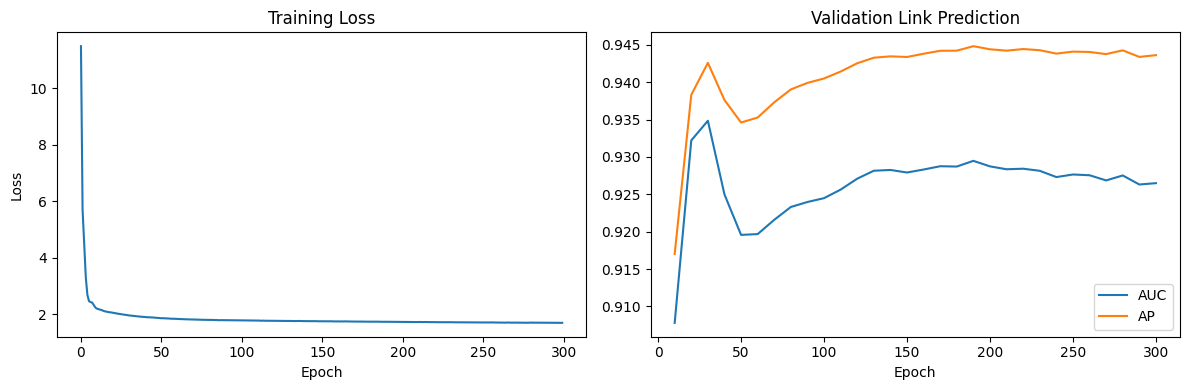

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

epochs_logged = [t[0] for t in val_aucs]
aucs = [t[1] for t in val_aucs]
aps  = [t[2] for t in val_aucs]

axes[1].plot(epochs_logged, aucs,  label="AUC")
axes[1].plot(epochs_logged, aps,   label="AP")
axes[1].set_title("Validation Link Prediction")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Final Test Set Evaluation

In [11]:
# Refresh embeddings on full graph before test evaluation
model.eval()
with torch.no_grad():
    model.encode(x, train_edges)

test_auc, test_ap = evaluate(model, data, split="test")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test AP:  {test_ap:.4f}")
print()
print("Baseline (random): AUC = 0.50, AP ≈ fraction of positive edges")

Test AUC: 0.9285
Test AP:  0.9462

Baseline (random): AUC = 0.50, AP ≈ fraction of positive edges


## 11. Extract Node Embeddings

We use μ (the mean of the learned posterior) as the final embedding for each node.
This is deterministic and noise-free — the right choice for downstream tasks.

In [12]:
model.eval()
with torch.no_grad():
    model.encode(x, train_edges)
    embeddings = model.mu.cpu()   # (N, LATENT_DIM)

# L2-normalize for cosine similarity via dot product
embeddings_norm = F.normalize(embeddings, p=2, dim=1)

print(f"Embedding matrix: {embeddings_norm.shape}")
print(f"Sample embedding (node 0): {embeddings_norm[0, :8]}")

Embedding matrix: torch.Size([37700, 64])
Sample embedding (node 0): tensor([ 0.1089, -0.0980,  0.1418, -0.0660, -0.0285, -0.2537,  0.2097,  0.3965])


## 12. Recommender System

Given a query user, we:
1. Compute cosine similarity between the query's embedding and all other nodes.
2. Exclude existing neighbors (already connected — not useful recommendations).
3. Return top-k nodes by similarity score.

This jointly uses both graph structure and node features, since both informed the VGAE encoder during training.

In [13]:
# Precompute adjacency set for fast neighbor lookup
adj_set = {}
edge_np = edge_index.numpy()
for src, dst in zip(edge_np[0], edge_np[1]):
    adj_set.setdefault(src, set()).add(dst)

def recommend(query_node, k=10, exclude_neighbors=True):
    """
    Return top-k recommended nodes for query_node.
    
    Similarity: cosine (dot product on L2-normalized embeddings).
    Excludes: query node itself and existing neighbors (if exclude_neighbors=True).
    """
    q_emb = embeddings_norm[query_node]          # (LATENT_DIM,)
    scores = embeddings_norm @ q_emb             # (N,) cosine similarities

    # Mask out query node and existing neighbors
    scores[query_node] = -1.0
    if exclude_neighbors:
        for nb in adj_set.get(query_node, []):
            scores[nb] = -1.0

    top_k_idx   = torch.topk(scores, k=k).indices.tolist()
    top_k_scores = torch.topk(scores, k=k).values.tolist()

    return list(zip(top_k_idx, top_k_scores))


# Demo
query = 42
recs = recommend(query, k=10)
print(f"Top-10 recommendations for user {query}:")
print(f"{'Rank':<6} {'Node':<10} {'Cosine Sim':<12} {'Shared Neighbors'}")
print("-" * 50)

q_neighbors = adj_set.get(query, set())
for rank, (node, score) in enumerate(recs, 1):
    shared = len(q_neighbors & adj_set.get(node, set()))
    print(f"{rank:<6} {node:<10} {score:<12.4f} {shared}")

Top-10 recommendations for user 42:
Rank   Node       Cosine Sim   Shared Neighbors
--------------------------------------------------
1      16371      0.9973       7
2      21411      0.9972       5
3      29078      0.9963       2
4      1735       0.9962       7
5      8946       0.9949       4
6      6631       0.9949       12
7      12506      0.9943       4
8      9880       0.9942       5
9      2556       0.9939       2
10     6452       0.9937       10


## 13. Proxy Evaluation: Precision@k on Held-Out Edges

A clean unsupervised evaluation for the recommender:

> For each user, we hold out some of their real connections (test edges). We then ask: does the recommender surface those held-out connections in its top-k?

**Precision@k** = (held-out connections in top-k) / k

No labels used — only the graph structure itself as ground truth.

## 14. Embedding Space Visualization (UMAP)

Project 64-dim embeddings to 2D. We color nodes by degree bucket to see
whether structural roles are separated in the learned space.

d:\Personal\second year\DS\clone\new\Spa-Former\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


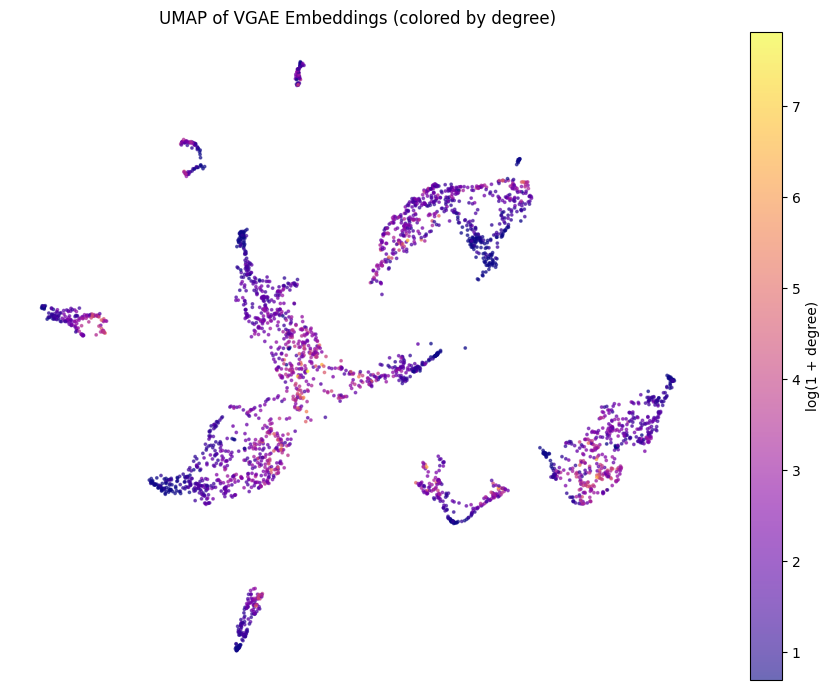

In [19]:
import umap

# Sample 3000 nodes for visualization — full 37k is too slow for UMAP in a notebook
sample_idx = np.random.choice(N, size=3000, replace=False)
emb_sample = embeddings_norm[sample_idx].numpy()

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
emb_2d = reducer.fit_transform(emb_sample)

# Color by log degree
deg_sample = np.log1p(degree[sample_idx].numpy())

plt.figure(figsize=(9, 7))
sc = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=deg_sample, cmap="plasma", s=3, alpha=0.6)
plt.colorbar(sc, label="log(1 + degree)")
plt.title("UMAP of VGAE Embeddings (colored by degree)")
plt.axis("off")
plt.tight_layout()
plt.show()

## 15. Community Structure Analysis (Post-hoc, not a training dependency)

We can run k-means or Louvain *on the learned embeddings* to analyze what structure VGAE discovered — but this is purely interpretive. The model never relied on community labels.

Clusters: 20
Size — min: 674, max: 3703, mean: 1885


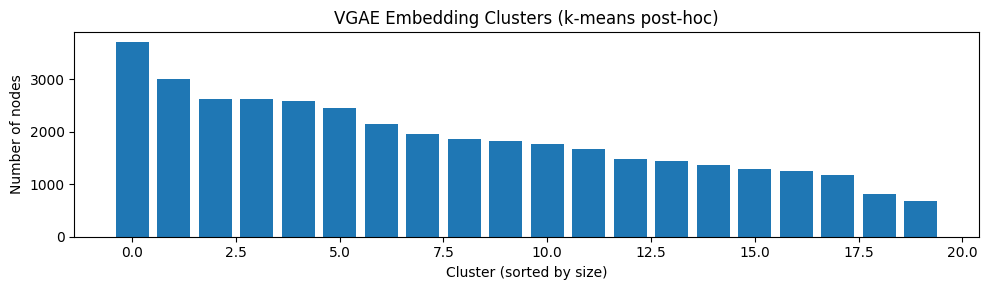

In [20]:
from sklearn.cluster import KMeans

N_CLUSTERS = 20

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_norm.numpy())

cluster_sizes = Counter(cluster_labels.tolist())
sizes = np.array([cluster_sizes[i] for i in range(N_CLUSTERS)])

print(f"Clusters: {N_CLUSTERS}")
print(f"Size — min: {sizes.min()}, max: {sizes.max()}, mean: {sizes.mean():.0f}")

# Visualize cluster sizes
plt.figure(figsize=(10, 3))
plt.bar(range(N_CLUSTERS), sorted(sizes, reverse=True))
plt.xlabel("Cluster (sorted by size)")
plt.ylabel("Number of nodes")
plt.title("VGAE Embedding Clusters (k-means post-hoc)")
plt.tight_layout()
plt.show()

## 16. Save Embeddings

In [21]:
os.makedirs("artifacts", exist_ok=True)

# Save raw embeddings (for further analysis)
torch.save(embeddings_norm, "artifacts/vgae_embeddings.pt")

# Save as numpy array
np.save("artifacts/vgae_embeddings.npy", embeddings_norm.numpy())

# Save model checkpoint
torch.save(model.state_dict(), "artifacts/vgae_model.pt")

print("Saved:")
print("  artifacts/vgae_embeddings.pt  — node embeddings (N, 64)")
print("  artifacts/vgae_embeddings.npy — same, numpy format")
print("  artifacts/vgae_model.pt       — model weights")

Saved:
  artifacts/vgae_embeddings.pt  — node embeddings (N, 64)
  artifacts/vgae_embeddings.npy — same, numpy format
  artifacts/vgae_model.pt       — model weights


## Notes

### Why this is genuinely unsupervised
The only supervision signal is the graph adjacency itself. We never use node labels, community assignments, or any external annotation. The KL term is self-regularizing.

### What the embeddings encode
Each node embedding encodes: (1) its own features via the GCN's feature transformation, (2) its 1-hop neighbors' features (after layer 1), (3) its 2-hop structural context (after layer 2), trained to be consistent with who the node is actually connected to.

### Mini-batch training (if OOM)
Replace full-batch encode with PyG's `NeighborLoader` for mini-batch sampling. The decoder stays the same; only the encoder forward changes to operate on sampled subgraphs.

### Hyperparameter guidance
- `LATENT_DIM`: 32–128 is typical. Lower = more compressed / less expressive.
- `BETA`: lower beta (0.1–0.5) loosens the KL constraint → richer embeddings but may overfit.
- `EPOCHS`: watch val AUC — stop when it plateaus.
- `PCA_DIM`: 64–256. Higher preserves more feature info but slows training.

In [22]:
def recall_at_k_with_candidates(k=10, num_eval_users=500, num_negatives=99):
    test_pos = data.test_pos_edge_index.numpy()
    
    test_targets = {}
    for src, dst in zip(test_pos[0], test_pos[1]):
        test_targets.setdefault(src, set()).add(dst)
    
    eval_users = [u for u in test_targets if len(test_targets[u]) >= 1]
    eval_users = random.sample(eval_users, min(num_eval_users, len(eval_users)))
    
    hits = []
    for user in eval_users:
        pos_targets = list(test_targets[user])
        
        # sample negatives — nodes not connected to user at all
        existing = adj_set.get(user, set()) | test_targets[user]
        negatives = []
        while len(negatives) < num_negatives:
            cand = random.randint(0, N-1)
            if cand != user and cand not in existing:
                negatives.append(cand)
        
        candidates = pos_targets + negatives
        
        # score all candidates
        q_emb = embeddings_norm[user]
        cand_embs = embeddings_norm[candidates]
        scores = (cand_embs @ q_emb).tolist()
        
        # rank and check if positive is in top-k
        ranked = sorted(zip(candidates, scores), key=lambda x: -x[1])
        top_k_nodes = [n for n, _ in ranked[:k]]
        
        hit = any(p in top_k_nodes for p in pos_targets)
        hits.append(int(hit))
    
    return np.mean(hits)

for k in [1, 5, 10]:
    score = recall_at_k_with_candidates(k=k)
    print(f"Recall@{k} (100 candidates): {score:.4f}  |  random baseline: {k/100:.4f}")

Recall@1 (100 candidates): 0.2560  |  random baseline: 0.0100
Recall@5 (100 candidates): 0.5060  |  random baseline: 0.0500
Recall@10 (100 candidates): 0.6500  |  random baseline: 0.1000
